# **MLP para Previsão de Churn com PyTorch** 🤖

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_excel('../data/raw/Telco_customer_churn.xlsx')
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [5]:
service_cols = [
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies'
]

df['services_count'] = (df[service_cols] != 'No').sum(axis=1)

df['has_online_security_backup'] = np.where(
    (df['Online Security'] == 'Yes') | (df['Online Backup'] == 'Yes'),
    1, 0
)

df['is_senior_alone'] = np.where(
    (df['Senior Citizen'] == 'Yes') & (df['Partner'] == 'No') & (df['Dependents'] == 'No'),
    1, 0
)

df['monthly_charge_per_tenure'] = df['Monthly Charges'] / (df['Tenure Months'] + 1)

df['is_long_contract'] = np.where(
    df['Contract'].isin(['One year', 'Two year']),
    1, 0
)

## 🧹 1. Preparação dos Dados para a Rede Neural

Nesta etapa, serão definidas a variável alvo, as variáveis explicativas e o pipeline de pré-processamento para alimentar a rede neural.

In [6]:
y = df['Churn Value']

colunas_excluir = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Label',
    'Churn Value',
    'Churn Score',
    'CLTV',
    'Churn Reason'
]

X = df.drop(columns=colunas_excluir)

In [7]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numéricas:", numeric_features)
print("\nCategóricas:", categorical_features)

Numéricas: ['Zip Code', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'services_count', 'has_online_security_backup', 'is_senior_alone', 'monthly_charge_per_tenure', 'is_long_contract']

Categóricas: ['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [8]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (4507, 26)
X_val: (1127, 26)
X_test: (1409, 26)


In [9]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [10]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [11]:
X_train_array = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_val_array = X_val_processed.toarray() if hasattr(X_val_processed, "toarray") else X_val_processed
X_test_array = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

In [12]:
X_train_tensor = torch.tensor(X_train_array, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_array, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_array, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [13]:
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## 🧠 2. Definição da Arquitetura da MLP

Nesta etapa, será definida a arquitetura da rede neural do tipo MLP, responsável por aprender padrões não lineares nos dados para previsão de churn.

In [14]:
input_dim = X_train_tensor.shape[1]

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

model = MLP(input_dim)
model

MLP(
  (model): Sequential(
    (0): Linear(in_features=1167, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [15]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 🔥 3. Treinamento da Rede Neural

O modelo será treinado utilizando batches de dados e monitoramento do desempenho no conjunto de validação, com aplicação de early stopping para evitar overfitting.

In [17]:
num_epochs = 50
patience = 5

best_val_loss = float('inf')
epochs_no_improve = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss_epoch = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        train_loss_epoch += loss.item()
    
    train_loss_epoch /= len(train_loader)
    train_losses.append(train_loss_epoch)
    
    model.eval()
    val_loss_epoch = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss_epoch += loss.item()
    
    val_loss_epoch /= len(val_loader)
    val_losses.append(val_loss_epoch)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss_epoch:.4f} | Val Loss: {val_loss_epoch:.4f}")
    
    if val_loss_epoch < best_val_loss:
        best_val_loss = val_loss_epoch
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print("Early stopping ativado!")
        break

model.load_state_dict(best_model_state)

Epoch 1/50 | Train Loss: 0.5203 | Val Loss: 0.4179
Epoch 2/50 | Train Loss: 0.4157 | Val Loss: 0.4017
Epoch 3/50 | Train Loss: 0.4006 | Val Loss: 0.3993
Epoch 4/50 | Train Loss: 0.3933 | Val Loss: 0.3990
Epoch 5/50 | Train Loss: 0.3784 | Val Loss: 0.4000
Epoch 6/50 | Train Loss: 0.3628 | Val Loss: 0.4007
Epoch 7/50 | Train Loss: 0.3504 | Val Loss: 0.4079
Epoch 8/50 | Train Loss: 0.3364 | Val Loss: 0.4164
Epoch 9/50 | Train Loss: 0.3176 | Val Loss: 0.4259
Early stopping ativado!


<All keys matched successfully>

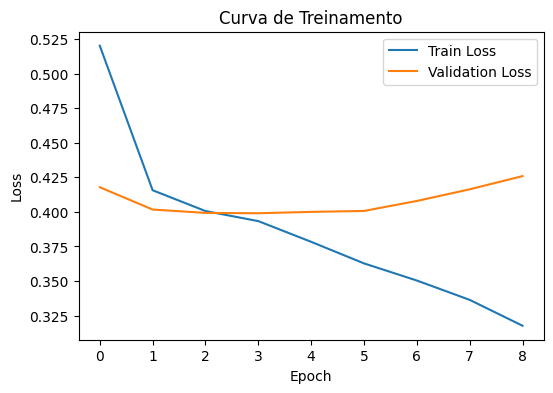

In [18]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Curva de Treinamento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 📊 4. Avaliação da MLP

Nesta etapa, a rede neural será avaliada no conjunto de teste, utilizando métricas adequadas ao problema de churn.

In [19]:
model.eval()

with torch.no_grad():
    y_prob_mlp = model(X_test_tensor).numpy().flatten()

y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

In [20]:
def avaliar_modelo(nome_modelo, y_true, y_pred, y_prob):
    resultados = {
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob)
    }

    print(f"Modelo: {nome_modelo}")
    print(f"Accuracy:  {resultados['accuracy']:.4f}")
    print(f"Precision: {resultados['precision']:.4f}")
    print(f"Recall:    {resultados['recall']:.4f}")
    print(f"F1-score:  {resultados['f1_score']:.4f}")
    print(f"ROC-AUC:   {resultados['roc_auc']:.4f}")
    print(f"PR-AUC:    {resultados['pr_auc']:.4f}")

    return resultados

In [21]:
resultado_mlp = avaliar_modelo("MLP", y_test.values, y_pred_mlp, y_prob_mlp)
resultado_mlp

Modelo: MLP
Accuracy:  0.7935
Precision: 0.6137
Recall:    0.5989
F1-score:  0.6062
ROC-AUC:   0.8373
PR-AUC:    0.6433


{'modelo': 'MLP',
 'accuracy': 0.7934705464868701,
 'precision': 0.6136986301369863,
 'recall': 0.5989304812834224,
 'f1_score': 0.6062246278755075,
 'roc_auc': 0.8372523185822419,
 'pr_auc': 0.6432977784626308}

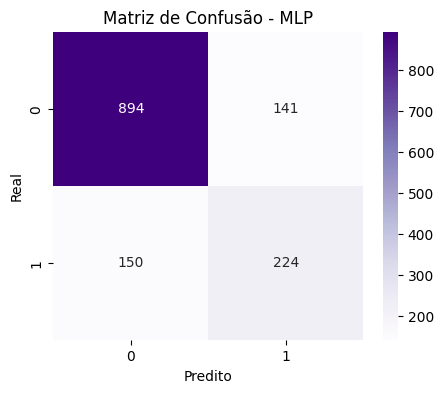

In [22]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5,4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusão - MLP')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

In [23]:
print(classification_report(y_test, y_pred_mlp, zero_division=0))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.60      0.61       374

    accuracy                           0.79      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [24]:
comparacao_mlp = pd.DataFrame([
    {
        "modelo": "Logistic Regression",
        "accuracy": 0.7899,
        "precision": 0.6161,
        "recall": 0.5535,
        "f1_score": 0.5831,
        "roc_auc": 0.8405,
        "pr_auc": 0.6368
    },
    {
        "modelo": "Gradient Boosting",
        "accuracy": 0.8027,
        "precision": 0.6558,
        "recall": 0.5401,
        "f1_score": 0.5924,
        "roc_auc": 0.8516,
        "pr_auc": 0.6674
    },
    resultado_mlp
])

comparacao_mlp.round(4)

,modelo,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,0.7899,0.6161,0.5535,0.5831,0.8405,0.6368
1,Gradient Boosting,0.8027,0.6558,0.5401,0.5924,0.8516,0.6674
2,MLP,0.7935,0.6137,0.5989,0.6062,0.8373,0.6433


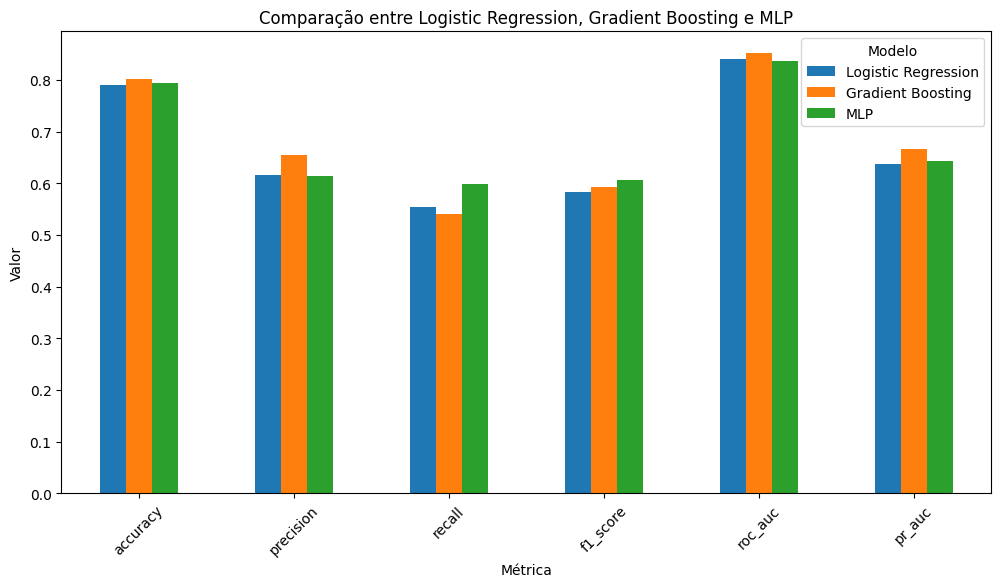

In [25]:
metricas_plot = comparacao_mlp.set_index('modelo')[['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']]

metricas_plot.T.plot(kind='bar', figsize=(12,6))
plt.title('Comparação entre Logistic Regression, Gradient Boosting e MLP')
plt.ylabel('Valor')
plt.xlabel('Métrica')
plt.xticks(rotation=45)
plt.legend(title='Modelo')
plt.show()

## 📊 5. Registro de Experimentos com MLflow

Nesta etapa, os resultados da rede neural MLP serão registrados no MLflow, permitindo rastrear parâmetros, métricas e artefatos do modelo.

In [26]:
import mlflow
from pathlib import Path

mlflow.set_experiment("churn_mlp")
Path("artifacts").mkdir(exist_ok=True)

with mlflow.start_run(run_name="MLP_PyTorch"):
    mlflow.log_param("model_name", "MLP")
    mlflow.log_param("input_dim", input_dim)
    mlflow.log_param("hidden_1", 64)
    mlflow.log_param("hidden_2", 32)
    mlflow.log_param("dropout_1", 0.3)
    mlflow.log_param("dropout_2", 0.2)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("num_epochs", len(train_losses))

    mlflow.log_metric("accuracy", resultado_mlp["accuracy"])
    mlflow.log_metric("precision", resultado_mlp["precision"])
    mlflow.log_metric("recall", resultado_mlp["recall"])
    mlflow.log_metric("f1_score", resultado_mlp["f1_score"])
    mlflow.log_metric("roc_auc", resultado_mlp["roc_auc"])
    mlflow.log_metric("pr_auc", resultado_mlp["pr_auc"])

2026/04/10 15:17:13 INFO mlflow.tracking.fluent: Experiment with name 'churn_mlp' does not exist. Creating a new experiment.


## 🏁 6. Conclusão

Nesta etapa, foi desenvolvida uma rede neural MLP em PyTorch para previsão de churn, utilizando pré-processamento estruturado, treinamento com batches e early stopping.

O modelo foi avaliado com métricas técnicas apropriadas e comparado aos modelos anteriores, permitindo analisar se a rede neural trouxe ganhos relevantes em relação aos baselines e ao melhor modelo da etapa de model engineering.

Com isso, o projeto passa a contar com uma abordagem baseada em redes neurais, ampliando a comparação entre diferentes estratégias de modelagem para o problema de churn.

💡 **Observação:**

A comparação entre os modelos indica que o Gradient Boosting apresenta o melhor desempenho geral, especialmente em métricas como ROC-AUC e PR-AUC.

Por outro lado, a MLP apresenta desempenho competitivo, com destaque para o recall, o que pode ser relevante em cenários onde a identificação de clientes propensos ao churn é prioritária.

Assim, a escolha do modelo pode depender do trade-off entre precisão e capacidade de detecção de churn.

## 📊 7. Registro de Experimentos com MLflow
Nesta etapa, os resultados da rede neural MLP serão registrados no MLflow, permitindo rastrear parâmetros, métricas e artefatos do modelo treinado.

In [27]:
import mlflow
from pathlib import Path

In [28]:
mlflow.set_experiment("churn_mlp")

<Experiment: artifact_location='file:///c:/Users/necca/OneDrive/Documentos/projeto_ml01/notebooks/mlruns/3', creation_time=1775845033556, experiment_id='3', last_update_time=1775845033556, lifecycle_stage='active', name='churn_mlp', tags={}, workspace='default'>

In [29]:
Path("artifacts").mkdir(exist_ok=True)

In [30]:
def salvar_matriz_confusao(cm, titulo, nome_arquivo, cmap='Purples'):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap)
    plt.title(titulo)
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.tight_layout()
    caminho = Path("artifacts") / nome_arquivo
    plt.savefig(caminho)
    plt.close()
    return str(caminho)

In [31]:
with mlflow.start_run(run_name="MLP_PyTorch"):

    # Parâmetros
    mlflow.log_param("model_name", "MLP")
    mlflow.log_param("input_dim", input_dim)
    mlflow.log_param("hidden_1", 64)
    mlflow.log_param("hidden_2", 32)
    mlflow.log_param("dropout_1", 0.3)
    mlflow.log_param("dropout_2", 0.2)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("num_epochs_executed", len(train_losses))
    mlflow.log_param("patience", patience)
    mlflow.log_param("criterion", "BCELoss")
    mlflow.log_param("optimizer", "Adam")

    # Métricas
    mlflow.log_metric("accuracy", resultado_mlp["accuracy"])
    mlflow.log_metric("precision", resultado_mlp["precision"])
    mlflow.log_metric("recall", resultado_mlp["recall"])
    mlflow.log_metric("f1_score", resultado_mlp["f1_score"])
    mlflow.log_metric("roc_auc", resultado_mlp["roc_auc"])
    mlflow.log_metric("pr_auc", resultado_mlp["pr_auc"])

    # Artefato: matriz de confusão
    caminho_cm_mlp = salvar_matriz_confusao(
        cm_mlp,
        "Matriz de Confusão - MLP",
        "cm_mlp.png",
        cmap='Purples'
    )
    mlflow.log_artifact(caminho_cm_mlp)

In [32]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.title('Curva de Treinamento - MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig("artifacts/mlp_training_curve.png")
plt.close()

mlflow.log_artifact("artifacts/mlp_training_curve.png")

💡 **Observação:**

O experimento da MLP foi registrado no MLflow com parâmetros, métricas e artefatos relevantes, como matriz de confusão e curva de treinamento.

Esse registro permite rastrear o comportamento do modelo e compará-lo com os resultados obtidos nas etapas anteriores, consolidando a avaliação da rede neural dentro do ciclo de vida do projeto.